## Import

In [1]:
# Import necessary libraries
from pyhgf.model import Network
from scipy.stats import halfnorm, norm
import copy
import pandas as pd
import time
import numpy as np
from voting import get_votes,generate_observations,generate_candidates,individual_vote
import altair as alt
import matplotlib.pyplot as plt
import colorsys
import altair as alt
import jax.numpy as jnp
import pandas as pd
import altair as alt
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import Pastel1

# Import JAX and related modules
from jax import jit
from jax import random, vmap
from jax.tree_util import Partial
from functools import partial as Partial

# Round one
https://en.wikipedia.org/wiki/Quadratic_voting
https://en.wikipedia.org/wiki/Ranked_voting#Theoretical_foundations_of_ranked_voting

## Parameters

In [2]:
# Parameters for the simulation
n_candidates = 12 
n_preferences = 10
n_agents = 100_000  
voting_system = "basic" # "basic", "ranked", "quadratic"

# Generate observations, tonic volatilities, candidate and mask
input_data = generate_observations(n_nodes=n_preferences, n_steps=100, scenario=1)
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)
candidate_list = generate_candidates(n_candidates=n_candidates, n_preferences=n_preferences)
mask = np.ones(n_candidates)

## Agents

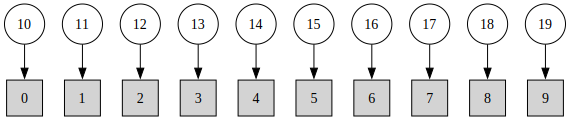

In [3]:
# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

In [4]:
# Setup and vectorize the get_votes function for the first round
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    n_preferences=n_preferences,
    input_data=input_data,
    mask=mask,
    voting_system=voting_system
)
vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes, dissatisfactions = vmap_get_votes_fn(tonic_volatilities, keys)

In [5]:
# Split into 10 simulations
sim_votes = np.array_split(votes, 100)
sim_diss = np.array_split(dissatisfactions, 100)  # ← nouveau : split par simulation

# Prepare a list to store proportions and dissatisfaction for each simulation
rows = []

for i, (vote_chunk, diss_chunk) in enumerate(zip(sim_votes, sim_diss)):
    total_votes = len(vote_chunk)
    unique, counts = np.unique(vote_chunk, return_counts=True)
    
    # Compute mean dissatisfaction per candidate for this simulation
    mean_diss = np.mean(diss_chunk, axis=0)  # shape = (n_candidates,)
    mean_diss = np.array(mean_diss, dtype=float)
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,  # simulation numbers 1–100
            'candidate': candidate,
            'proportion': count / total_votes,
            'mean_dissatisfaction': mean_diss[candidate]  # ← nouvelle colonne
        })

# Convert to DataFrame
df_simulations = pd.DataFrame(rows)

# Optional: convert candidate to categorical for Altair
df_simulations['candidate'] = df_simulations['candidate'].astype('category')
df_simulations['candidate_id'] = df_simulations['candidate'].cat.codes

df_simulations

,simulation_number,candidate,proportion,mean_dissatisfaction,candidate_id
0,1,0,0.094,3.588609,0
1,1,1,0.027,7.683309,1
2,1,2,0.009,1.854572,2
3,1,3,0.214,17.941645,3
4,1,5,0.069,5.420020,4
...,...,...,...,...,...
1029,100,7,0.005,17.356844,6
1030,100,8,0.190,21.345600,7
1031,100,9,0.029,-4.847749,8
1032,100,10,0.001,-0.889860,9


In [10]:
# Color scale for candidates
all_candidates = df_simulations['candidate_id'].unique()
color_scale = alt.Scale(domain=sorted(all_candidates), scheme='pastel1')

# Sélections
highlight = alt.selection_point(fields=['candidate_id'], on='mouseover', empty='all')
candidate_select = alt.selection_point(fields=['candidate_id'], bind='legend', empty='all')

# Votes chart
votes_chart = (
    alt.Chart(df_simulations)
    .mark_area(opacity=0.85)
    .encode(
        x=alt.X('simulation_number:N', title='Simulation Number'),
        y=alt.Y('proportion:Q', stack='center', title='Vote Proportion', axis=alt.Axis(format='.0%')),
        color=alt.Color('candidate_id:N', scale=color_scale, legend=alt.Legend(title='Candidate')),
        opacity=alt.condition(highlight, alt.value(1), alt.value(0.2)),
        tooltip=[
            alt.Tooltip('candidate:N', title='Candidate'),
            alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
            alt.Tooltip('mean_dissatisfaction:Q', title='Mean Dissatisfaction', format='.2f'),
            alt.Tooltip('simulation_number:N', title='Simulation')
        ]
    )
    .add_params(highlight, candidate_select)
    .transform_filter(candidate_select)
    .properties(width=1000, height=250)
)

votes_chart

alt.Chart(...)

In [12]:
# Identify the winners
winners = (
    df_simulations
    .loc[df_simulations.groupby("simulation_number")["proportion"].idxmax()]
)

# Compute mean dissatisfaction for each winner across simulations
df_wins = (
    winners.groupby("candidate_id")
    .agg(
        wins=("candidate_id", "count"),
        mean_dissatisfaction=("mean_dissatisfaction", "mean")  # ← nouvelle colonne
    )
    .reset_index()
)

# Define color scale
all_candidates = df_simulations['candidate_id'].unique()
color_scale = alt.Scale(domain=sorted(all_candidates), scheme='pastel1')

# Create histogram of wins
hist = (
    alt.Chart(df_wins)
    .mark_bar()
    .encode(
        x=alt.X("candidate_id:N", title="Candidate", sort="-y"),
        y=alt.Y("wins:Q", title="Number of Wins"),
        color=alt.Color("candidate_id:N", scale=color_scale, legend=alt.Legend(title="Candidate")),
        tooltip=[
            alt.Tooltip("candidate_id:N", title="Candidate"),
            alt.Tooltip("wins:Q", title="Number of Wins"),
            alt.Tooltip("mean_dissatisfaction:Q", title="Mean Dissatisfaction", format=".2f")  # ← tooltip ajouté
        ]
    )
    .properties(
        width=600,
        height=400,
        title="Histogram of Candidate Wins Across Simulations"
    )
)

hist

alt.Chart(...)

# Round two

In [18]:
# For each simulation select the two best candidates
best_two_candidates = (
    df_simulations.groupby('simulation_number', group_keys=False)
    .apply(lambda x: x.nlargest(2, 'proportion'))
)
best_two_candidates

# Split tonic volatilities into chunks for second round
tonic_volatilities_chunks = np.array_split(tonic_volatilities, 100)
n_agents = 1000
results = []  # on accumule toutes les simulations ici

for simulation_number, tonic_chunk in enumerate(tonic_volatilities_chunks, start=1):

    # Sélectionne seulement les 2 meilleurs candidats pour cette simulation
    candidate_indices = best_two_candidates.loc[
        best_two_candidates['simulation_number'] == simulation_number,
        'candidate'
    ].cat.codes.values

    # Crée le masque
    mask = jnp.zeros(n_candidates, dtype=bool).at[candidate_indices].set(True)

    # Vectorized vote function
    get_votes_fn = Partial(
        individual_vote,
        network=network,
        candidates=candidate_list,
        n_preferences=n_preferences,
        input_data=input_data,
        mask=mask,
        voting_system=voting_system
    )
    vmap_get_votes_fn = vmap(get_votes_fn)

    # Random keys
    key = random.PRNGKey(simulation_number)  # deterministic per simulation
    keys = random.split(key, n_agents)

    # Compute votes
    votes, dissatisfactions = vmap_get_votes_fn(tonic_chunk, keys)

    # Count votes
    unique, counts = np.unique(np.array(votes), return_counts=True)
    proportions = counts / n_agents

    for u, p in zip(unique, proportions):
        # moyenne d’insatisfaction pour les agents qui ont voté pour u
        mean_diss = float(np.mean(np.array(dissatisfactions)[np.array(votes) == u]))

        results.append({
            "simulation_number": simulation_number,
            "candidate_id": u,
            "proportion": p,
            "mean_dissatisfaction": mean_diss
        })
# DataFrame final
df_votes = pd.DataFrame(results)

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_32476/3347868770.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, 'proportion'))


In [21]:
# Color scale
all_candidates = df_votes['candidate_id'].unique()
color_scale = alt.Scale(domain=sorted(all_candidates), scheme='pastel1')

# Hover highlight
highlight = alt.selection_point(
    fields=['candidate_id'],
    on='mouseover',
    empty='all'
)

# Multi-select via legend
candidate_select = alt.selection_point(
    fields=['candidate_id'],
    bind='legend',
    empty='all'
)

# Area chart pour proportions
votes_chart = alt.Chart(df_votes).mark_area(opacity=0.85).encode(
    x=alt.X('simulation_number:N', title='Simulation Number'),
    y=alt.Y('proportion:Q', stack='center', title='Vote Proportion', axis=alt.Axis(format='.0%')),
    color=alt.Color('candidate_id:N', scale=color_scale, legend=alt.Legend(title='Candidate')),
    opacity=alt.condition(highlight, alt.value(1), alt.value(0.2)),
    tooltip=[
        alt.Tooltip('candidate_id:N', title='Candidate'),
        alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
        alt.Tooltip('mean_dissatisfaction:Q', title='Mean Dissatisfaction', format='.2f'),
        alt.Tooltip('simulation_number:N', title='Simulation')
    ]
).add_params(highlight, candidate_select
).transform_filter(candidate_select
).properties(width=1000, height=250, title="Evolution of Vote Proportions – Simulations")

votes_chart

alt.Chart(...)

In [23]:
# Identify the winners (déjà fait)
winners = (
    df_votes
    .loc[df_votes.groupby("simulation_number")["proportion"].idxmax()]
)

# Count the wins
df_wins = winners["candidate_id"].value_counts().reset_index()
df_wins.columns = ["candidate_id", "wins"]

# Compute mean dissatisfaction of winners
df_diss = (
    winners.groupby("candidate_id")["mean_dissatisfaction"]
    .mean()
    .reset_index()
    .rename(columns={"mean_dissatisfaction": "avg_dissatisfaction"})
)

# Merge wins + dissatisfaction
df_wins = df_wins.merge(df_diss, on="candidate_id", how="left")

# Define color scale
all_candidates = df_simulations['candidate_id'].unique()
color_scale = alt.Scale(domain=sorted(all_candidates), scheme='pastel1')

# Histogram of wins with dissatisfaction in tooltip
hist = (
    alt.Chart(df_wins)
    .mark_bar()
    .encode(
        x=alt.X("candidate_id:N", title="Candidate", sort="-y"),
        y=alt.Y("wins:Q", title="Number of Wins"),
        color=alt.Color("candidate_id:N", scale=color_scale, legend=alt.Legend(title="Candidate")),
        tooltip=[
            alt.Tooltip("candidate_id:N", title="Candidate"),
            alt.Tooltip("wins:Q", title="Wins"),
            alt.Tooltip("avg_dissatisfaction:Q", title="Avg Dissatisfaction", format=".2f")
        ]
    )
    .properties(
        width=600,
        height=400,
        title="Histogram of Candidate Wins Across Simulations (with Dissatisfaction)"
    )
)

hist

alt.Chart(...)

# Plot trajectories

In [ ]:
# Définir les paramètres globaux pour la police
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Définir les styles de ligne (tous des traits pleins)
line_styles = ["-"] * 10  # Tous les styles de ligne sont des traits pleins

# Créer une figure avec 3 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True, facecolor='#f9f9f9')

# Liste des préférences et leurs indices correspondants
preferences = [0, 1, 2]  # Indices pour pref 1, pref 2, pref 4
pref_labels = ['Preference 1', 'Preference 2', 'Preference 3']

# Générer une palette de couleurs pastel
def generate_pastel_colors(n):
    pastel_colors = []
    for i in range(n):
        hue = i / n  # Distribuer les teintes uniformément
        saturation = 0.4  # Saturation légèrement réduite pour des couleurs encore plus pastel
        lightness = 0.85  # Luminosité plus élevée pour des couleurs très claires
        rgb = colorsys.hls_to_rgb(hue, lightness, saturation)
        pastel_colors.append(rgb)
    return pastel_colors

pastel_colors = generate_pastel_colors(n_agents)

for idx, pref in enumerate(preferences):
    ax = axes[idx]
    ax.set_facecolor('#f9f9f9')  # Fond du graphique légèrement plus clair
    for n_agents in range(n_agents):
        # Utiliser la couleur pastel correspondante
        color = pastel_colors[n_agents]
        # Définir la transparence
        alpha = 0.4 + 0.6 * (n_agents / (n_agents+1))  # Safe range: 0.4–1.0

        ax.plot(
            nodes_traje[pref]["expected_mean"][n_agents],
            label=f'Agent {n_agents + 1}' if idx == 0 else "",
            color=color,
            linestyle=line_styles[n_agents % len(line_styles)],
            linewidth=1.5,  # Lignes un peu plus fines
            alpha=alpha
        )
    ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax.set_title(f'Trajectory of Expected Mean ({pref_labels[idx]})', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.5)  # Grille très subtile

    # Ajouter une bordure subtile autour de chaque sous-graphique
    for spine in ax.spines.values():
        spine.set_edgecolor('#e0e0e0')  # Couleur de bordure très claire
        spine.set_linewidth(0.8)

# Ajouter une légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title="Agents", facecolor='#f9f9f9', edgecolor='#e0e0e0')

# Ajouter un titre global
fig.suptitle('Trajectories of Expected Means for Different Preferences', fontsize=16, fontweight='bold', y=1.02)

# Ajuster les marges et l'espacement
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Ajustement pour le titre global

plt.show()
